### 🤖 What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [34]:
import os
# from langchain.agents import create_agent
# from langgraph.prebuilt import create_react_agent
from langchain_classic.agents import Tool
from langchain_classic.tools import WikipediaQueryRun
from langchain_classic.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, StateGraph,START
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

In [35]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------
from langchain_ollama import OllamaEmbeddings
# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

# embedding = OpenAIEmbeddings()
embedding = OllamaEmbeddings(model="llama3.2:latest")
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [36]:
retriever.invoke("what are autonomous agents")

[Document(id='4fd8cffd-6d0c-4d60-bcff-defce36fcccc', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [37]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [38]:
retriever_tool_func("what are autonomous agents")

📚 Using RAGRetriever tool


'Memory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model to learn.\nLong-term memory: This provides the agent with the capability to retain and recall (infinite) information over extended periods, often by leveraging an external vector store and fast retrieval.\n\n\nTool use\nPrompt LM with 100 most recent observations and to generate 3 most salient high-level questions given a set of observations/statements. Then ask LM to answer those questions.\n\n\nPlanning & Reacting: translate the reflections and the environment information into actions\nAPI-Bank (Li et al. 2023) is a benchmark for evaluating the performance of tool-augmented LLMs. It contains 53 commonly used API tools, a complete tool-augmented LLM workflow, and 264 annotated dialogues that involve 568 API calls. The selection of APIs is quite diverse, including search engines, calculator, calendar queries, smart home control, schedule manage

In [39]:
retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)
retriever_tool
print(retriever_tool.name)

RAGRetriever


In [40]:
wiki_tool=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\ArnavBhatia\\anaconda3\\envs\\llms\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [41]:
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
tools=[retriever_tool,wiki_tool]
react_node=create_react_agent(tools=tools, model=init_chat_model("ollama:llama3.2:latest"))

C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_37516\2217523955.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node=create_react_agent(tools=tools, model=init_chat_model("ollama:llama3.2:latest"))


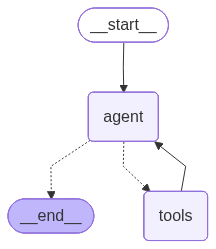

In [42]:
from IPython.display import Image,display
display(Image(react_node.get_graph().draw_mermaid_png()))

Agent State

In [43]:
from pydantic import BaseModel
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

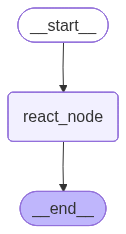

In [44]:
builder=StateGraph(AgentState)

builder.add_node("react_node",react_node)
builder.set_entry_point("react_node")
builder.add_edge("react_node",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool
📚 Using RAGRetriever tool

✅ Final Answer:
 An agent loop, also known as an autonomous agent or self-modifying code, refers to a control structure that allows a computer program to execute tasks iteratively with the goal of achieving a specific objective. This concept is closely related to the idea of artificial intelligence (AI) and autonomous systems.

In Wikipedia's description of autonomous agents, it mentions that they are capable of interacting with their environment, adapting to new situations, and learning from experience. The agent loop plays a crucial role in enabling these capabilities by allowing the agent to iterate through different tasks, adjust its behavior based on feedback, and refine its decision-making process.

The Wikipedia article also discusses the importance of memory in autonomous agents, distinguishing between short-term and long-term memory. Short-term memory refers to the ability of an agent to retain information for a limited peri

### Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [46]:
import os
from typing import Annotated, Sequence, TypedDict
from langchain_classic.agents import Tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.tools import WikipediaQueryRun
from langchain_classic.utilities import WikipediaAPIWrapper
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_community.document_loaders import TextLoader

In [48]:
llm=init_chat_model("ollama:llama3.2:latest")
llm

ChatOllama(model='llama3.2:latest')

In [50]:
### Generic function to create a retireval tool
def make_retriever_tool_from_text(file,name,desc):
    docs=TextLoader(file,encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()

    def tool_func(query:str)->str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name,description=desc,func=tool_func)

def wiki_tool_func(query:str)->str:
    print("🧪 Using Wikipedia Tool...")
    return WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()).invoke(query)
# Wikipedia Tool
wiki_tool = Tool(
    name="Wikipedia",
    description="Use this tool to fetch general world knowledge from Wikipedia.",
    func=wiki_tool_func
)



# ArXiv Tool
def arxiv_search(query: str) -> str:
    print("🧪 Searching ArXiv...")
    results = ArxivLoader(query).load()
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."

arxiv_tool = Tool(
    name="ArxivSearch",
    description="Use this tool to fetch recent academic papers on technical topics.",
    func=arxiv_search
)


In [52]:
internal_tool_1=make_retriever_tool_from_text(
    "sample_docs.txt",
    "InternalTechDocs",
    "Search internal tech documents for proprietary architecture and methods."
)
internal_tool_1

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_2

Tool(name='InternalResearchNotes', description='Search internal research notes for experimental results and agent designs.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x00000210EB6EC2C0>)

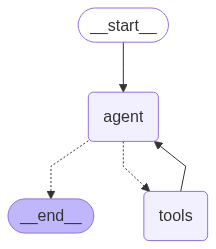

In [ ]:
tools=[wiki_tool,arxiv_tool,internal_tool_1,internal_tool_2]

react_node=create_react_agent(llm,tools)
react_node

In [53]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

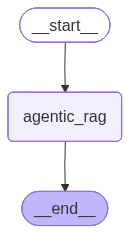

In [54]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph


In [55]:
query = "What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"

state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool

✅ Final Answer:
 Based on the internal research notes, transformer variants have been extensively explored in recent years. Some notable variants include:

1. **BERT (Bidirectional Encoder Representations from Transformers)**: Introduced by Devlin et al. (2019), BERT is a language model that uses a multi-task learning approach to pre-train its weights on multiple tasks simultaneously. This approach enables the model to learn contextualized representations of words and phrases, leading to significant improvements in natural language processing (NLP) tasks.
2. **DistilBERT**: DistilBERT is a smaller version of BERT, which was introduced by Sanh et al. (2020). It achieves similar performance to BERT while using fewer parameters and being more computationally efficient.
3. **Albert**: Introduced by Hashimoto et al. (2019), Albert (ALBERT) is another pre-trained language model that uses a different approach to pre-training. It combines the strengths of both BERT a